# ATLIQ Hospitality Management

Imagine **Atliq Grands** to be a chain of hotels spread across different cities in India. They offer different rooms that cater to varying needs such as business, luxury, suits etc. One may book room by any one of the following methods such as, 
* ATLIQ GRAND website 
* Third party apps such as *Make your trip*,*tripster* etc. 

Recently Atliq saw a cutthroat competition with both it's revenue and customer base taking a hit. It hired several *Analysts* to provide data-driven decision insights.

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

### IMPORT DIFFERENT DATAFRAMES
Here we fetch all different tables both *fact* and *dimensions* such as, 
* `Bookings` - Fact/Sales table. 

The remaining are *dimensions* such as, 
* `Date`
* `Hotels` 
* `Rooms`
* `Aggregate Bookings`

In [102]:
df_bookings = pd.read_csv('./Datasets/Atliq_hospitality/fact_bookings.csv')

In [248]:
df_date = pd.read_csv('./Datasets/Atliq_hospitality/dim_date.csv')
df_hotels = pd.read_csv('./Datasets/Atliq_hospitality/dim_hotels.csv')
df_rooms = pd.read_csv('./Datasets/Atliq_hospitality/dim_rooms.csv')
df_agg_bookings = pd.read_csv('./Datasets/Atliq_hospitality/fact_aggregated_bookings.csv')
df_august_bookings = pd.read_csv('./Datasets/Atliq_hospitality/new_data_august.csv')

### CHECK BOOKINGS RELATED DATA
Below we check bookings related data such as, 
* Different room types. 
* Different booking platforms people used to book rooms. 
* No of different guests people booked rooms for. 
Others.

In [104]:
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920


In [105]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


In [106]:
# check dataframe shape
df_bookings.shape

(134590, 12)

In [107]:
# check no of different rooms
df_bookings['room_category'].unique()

array(['RT1', 'RT2', 'RT3', 'RT4'], dtype=object)

In [108]:
# check different platforms customers used to book room
df_bookings.booking_platform.unique()

array(['direct online', 'others', 'logtrip', 'tripster', 'makeyourtrip',
       'journey', 'direct offline'], dtype=object)

In [109]:
# check for how many different no of guests people booked rooms
df_bookings.no_guests.unique()

array([ -3.,   2.,  -2.,   4.,   1.,   3.,  nan,   6.,   5., -10., -12.,
        -6.,  -4., -17.,  -1.])

From above we observe that there exists booking made for *negative no of guests* which cannot be possible hence we replace those as *null*.

In [110]:
# no of bookings made from different platforms
print('No Of Bookings Across Different Platforms\n')
df_bookings.booking_platform.value_counts()

No Of Bookings Across Different Platforms



booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


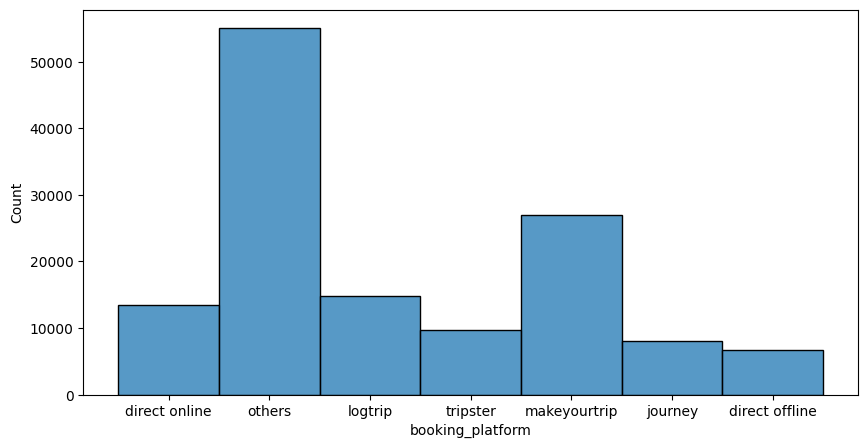

In [111]:
# VISUALIZE BOOKINGS ACROSS DIFFERENT PLATFORMS
plt.figure(figsize=(10,5))
sns.histplot(data=df_bookings,x='booking_platform')
plt.show()

INFERENCE:
* `Others` has the largest customer booking from followed by `makeyourtrip` with the least no of customers opting for `Offline` booking.

### EXPLORE HOTELS TABLE


In [112]:
df_hotels.head()

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [113]:
# check different categories of hotels Atliq offers
df_hotels.category.unique()

array(['Luxury', 'Business'], dtype=object)

In [114]:
# check which cities are the hotels located in
df_hotels.city.unique()

array(['Delhi', 'Mumbai', 'Hyderabad', 'Bangalore'], dtype=object)

In [115]:
# check what are the hotel chain names of Atliq are
df_hotels.property_name.unique()

array(['Atliq Grands', 'Atliq Exotica', 'Atliq City', 'Atliq Blu',
       'Atliq Bay', 'Atliq Palace', 'Atliq Seasons'], dtype=object)

In [116]:
# check hotel distribution according to category
df_hotels.category.value_counts()

category
Luxury      16
Business     9
Name: count, dtype: int64

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


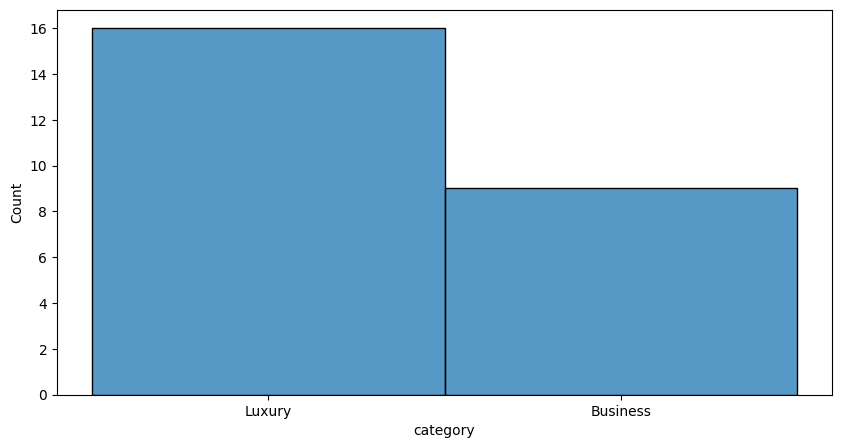

In [117]:
# visualize distribution of hotel types
plt.figure(figsize=(10,5))
sns.histplot(data=df_hotels,x='category')
plt.show()

In [118]:
# check hotel distribution by cities
df_hotels.city.value_counts()

city
Mumbai       8
Hyderabad    6
Bangalore    6
Delhi        5
Name: count, dtype: int64

### EXPLORE AGGREGATE BOOKINGS
`Aggregate Bookings` holds information about preporty & roomwise successfull bookings made across different dates.

In [119]:
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0
4,16558,1-May-22,RT1,18,19.0


In [120]:
df_agg_bookings.describe()

,property_id,successful_bookings,capacity
count,9200.000000,9200.000000,9198.000000
mean,18040.640000,14.655761,25.280496
std,1099.818325,7.736170,11.442080
min,16558.000000,1.000000,3.000000
25%,17558.000000,9.000000,18.000000
50%,17564.000000,14.000000,25.000000
75%,18563.000000,19.000000,34.000000
max,19563.000000,123.000000,50.000000


In [121]:
# check for how many different dates bookings were made
df_agg_bookings.check_in_date.min(),df_agg_bookings.check_in_date.max()

('1-Jul-22', '9-May-22')

In [122]:
# check property IDs booked
df_agg_bookings.property_id.unique()

array([16559, 19562, 19563, 17558, 16558, 17560, 19558, 19560, 17561,
       16560, 16561, 16562, 16563, 17559, 17562, 17563, 18558, 18559,
       18561, 18562, 18563, 19559, 19561, 17564, 18560])

In [123]:
# check distribution of bookings across different property IDs
df_agg_bookings.groupby(['property_id'])['successful_bookings'].agg(['count'])

,count
property_id,
16558,368
16559,368
16560,368
16561,368
16562,368
16563,368
17558,368
17559,368
17560,368


**INFERENCE:** 
* From above we notice that across different property no of bookings made were similar.

In [124]:
# find capacity of different room types across different properties
propertyID_and_roomwise_capacity_df = df_agg_bookings.groupby(['property_id','room_category'])['capacity'].agg(['max']).rename(columns={'max':'Capacity'})

In [125]:
propertyID_and_roomwise_capacity_df.head(4)

Capacity
property_id room_category          
16558       RT1                19.0
            RT2                22.0
            RT3                 8.0
            RT4                 3.0

In [126]:
# check property ID and roomtype with maximum capacity
propertyID_and_roomtype_with_max_capacity = propertyID_and_roomwise_capacity_df[propertyID_and_roomwise_capacity_df['Capacity']==propertyID_and_roomwise_capacity_df['Capacity'].max()]
propertyID_and_roomtype_with_max_capacity.head()

,,Capacity
property_id,room_category,
17558,RT2,50.0


**INFERENCE:** 
* *Room type-2* belonging to property ID *17558* has the maximum no of capacity.

In [127]:
# check days on which bookings were more than capacity
days_with_bookings_exceeding_capacity = np.unique(df_agg_bookings[df_agg_bookings['successful_bookings']>df_agg_bookings['capacity']]['check_in_date'].values)
days_with_bookings_exceeding_capacity


array(['1-May-22', '11-Jun-22', '2-Jul-22', '25-Jul-22', '31-Jul-22'],
      dtype=object)

**INFERENCE:** 
* On dates *1-May, 11-Jun, 2-Jul, 25-Jul & 31-Jul in 2022* bookings for respective rooms went beyond their capacity.

### DATA CLEANING
Here we look at bookings data and check for `ambiguous entries`, `null` etc. and replace them with suitable values. 



In [128]:
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920


In [129]:
# check for no of entries with negative or zero as no of guests.
bookings_with_invalid_guestcount = df_bookings[df_bookings.no_guests<=0]
print(f'{len(bookings_with_invalid_guestcount)} entries with invalid no of guests.')

9 entries with invalid no of guests.


In [130]:
bookings_with_invalid_guestcount

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
17924,May122218559RT44,18559,12/5/2022,12/5/2022,14-05-22,-10.0,RT4,direct online,NaN,No Show,20900,20900
18020,May122218561RT22,18561,8/5/2022,12/5/2022,14-05-22,-12.0,RT2,makeyourtrip,NaN,Cancelled,9000,3600
18119,May122218562RT311,18562,5/5/2022,12/5/2022,17-05-22,-6.0,RT3,direct offline,5.0,Checked Out,16800,16800
18121,May122218562RT313,18562,10/5/2022,12/5/2022,17-05-22,-4.0,RT3,direct online,NaN,Cancelled,14400,5760
56715,Jun082218562RT12,18562,5/6/2022,8/6/2022,13-06-22,-17.0,RT1,others,NaN,Checked Out,6500,6500
119765,Jul202219560RT220,19560,19-07-22,20-07-22,22-07-22,-1.0,RT2,others,NaN,Checked Out,13500,13500
134586,Jul312217564RT47,17564,30-07-22,31-07-22,1/8/2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760


In [131]:
# let's check whether will it be good to remove the above entries or come up with some statistics to replace these.
print(f'Invalid guest entry forms {(len(bookings_with_invalid_guestcount)/len(df_bookings))*100}% of the total entries')

Invalid guest entry forms 0.006686975258191545% of the total entries


**INFERENCE:** 
* Since only 0.0066% of the records have invalid entries we can omit them.

In [132]:
# keep entries with positive guest count
df_bookings = df_bookings[~(df_bookings['no_guests']<=0)].reset_index()

In [133]:
# do a sanity check to see whether there exists any invalid guest count
df_bookings['no_guests'].min()

1.0

In [134]:
# check for invalid revenue generated 
df_bookings.revenue_generated.min(),df_bookings.revenue_generated.max()

(6500, 28560000)

**INFERENCE:**
* A single booking worth **~3 Cr** is ambiguous and hence must be removed. This indicates an outlier. 
* There exists several methods for outlier removal such as, 
    1. IQR. 
    2. Std deviation - Values outside 3*std from mean are treated as outliers and removed. etc.

In [135]:
def Compute_bounds_for_attribute_basis_IQR(df,attribute):
    '''
    Function to return lower and upper bound for acceptable range of values for an attribute to remove outliers.
    Args:
    1. df -> dataframe.
    2. attribute -> Attribute for which outlier is to be detected & removed.
    '''
    # sort values in ascending
    attribute_sorted = np.asarray(df[attribute].sort_values())
    
    # find Q1 pos
    if len(attribute_sorted)%2 == 0:
        Q2_idx = int(len(attribute_sorted)/2)
    else:
        Q2_idx = int((len(attribute_sorted)-1)/2)

    # find Q2 pos
    if Q2_idx%2 == 0:
        Q1_idx = int(Q2_idx/2)
    else:
        Q1_idx = int((Q2_idx-1)/2)

    # find Q3 pos
    if ((len(attribute_sorted)-1)-Q2_idx)%2 == 0:
        Q3_idx = Q2_idx + int(((len(attribute_sorted)-1)-Q2_idx)/2)
    else:
        Q3_idx = Q2_idx + int((((len(attribute_sorted)-1)-Q2_idx)-1)/2)
    
    Q1 = attribute_sorted[Q1_idx]
    Q3 = attribute_sorted[Q3_idx]
    IQR = Q3-Q1

    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR

    return lower_bound,upper_bound

In [136]:
revgen_low,revgen_high = Compute_bounds_for_attribute_basis_IQR(df_bookings,'revenue_generated')
revgen_low,revgen_high

(-2250.0, 30150.0)

**INFERENCE:**
* Hence from above if *revenue_generated* falls outside the range -2250 to 30150 then we consider it as outlier & omit. 
* Also *revenue_generated* cannot be negative. 

In [137]:
# check for range of values for revenue generated
df_bookings.revenue_generated.min(),df_bookings.revenue_generated.max()

(6500, 28560000)

In [138]:
# display outliers
revenue_generated_outliers_df = df_bookings[(df_bookings['revenue_generated']<revgen_low) | (df_bookings['revenue_generated']>revgen_high)]

In [139]:
print(f'No of outliers for revenue generated is: {len(revenue_generated_outliers_df)} which forms {(len(revenue_generated_outliers_df)/len(df_bookings))*100}% of the total entries.')

No of outliers for revenue generated is: 6288 which forms 4.672279147873771% of the total entries.


In [140]:
revenue_generated_outliers_df.head()

,index,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
109,111,May012216559RT32,16559,29-04-22,1/5/2022,2/5/2022,6.0,RT3,direct online,NaN,Checked Out,28560000,28560
135,137,May012216559RT41,16559,27-04-22,1/5/2022,7/5/2022,4.0,RT4,others,NaN,Checked Out,38760,38760
136,138,May012216559RT42,16559,11/4/2022,1/5/2022,3/5/2022,2.0,RT4,direct offline,NaN,Cancelled,32300,12920
137,139,May012216559RT43,16559,1/5/2022,1/5/2022,2/5/2022,6.0,RT4,tripster,3.0,Checked Out,45220,45220


In [141]:
revenue_generated_outliers_df.set_index('index',inplace=True)
revenue_generated_outliers_df.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
index,,,,,,,,,,,,
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
111,May012216559RT32,16559,29-04-22,1/5/2022,2/5/2022,6.0,RT3,direct online,NaN,Checked Out,28560000,28560
137,May012216559RT41,16559,27-04-22,1/5/2022,7/5/2022,4.0,RT4,others,NaN,Checked Out,38760,38760
138,May012216559RT42,16559,11/4/2022,1/5/2022,3/5/2022,2.0,RT4,direct offline,NaN,Cancelled,32300,12920
139,May012216559RT43,16559,1/5/2022,1/5/2022,2/5/2022,6.0,RT4,tripster,3.0,Checked Out,45220,45220


In [143]:
df_bookings.head()

,index,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
1,2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
2,4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
3,5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
4,6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640


In [144]:
# set 'index' column as index of dataframe
df_bookings.set_index('index',inplace=True,drop=True)
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
index,,,,,,,,,,,,
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640


In [148]:
# remove outliers in revenue generated
df_bookings = df_bookings[~(df_bookings.index.isin(revenue_generated_outliers_df.index))]
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
index,,,,,,,,,,,,
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100


In [151]:
df_bookings['revenue_generated'].describe()

count    128293.000000
mean      13992.962165
std        4996.646724
min        6500.000000
25%        9750.000000
50%       13500.000000
75%       16830.000000
max       29260.000000
Name: revenue_generated, dtype: float64

In [155]:
RT4_bookings_df =  df_bookings[df_bookings['room_category']=='RT4']
RT4_bookings_df['revenue_realized'].describe()

count     9788.000000
mean     19929.245198
std       7098.905952
min       7600.000000
25%      19000.000000
50%      19000.000000
75%      26600.000000
max      29260.000000
Name: revenue_realized, dtype: float64

In [157]:
# check presence of null values in dataframe
df_bookings.isna().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                3
room_category            0
booking_platform         0
ratings_given        74319
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

**INFERENCE:**
* From above we observe *ratings_given* to have several NA entries but in reality that justifies since many customers may not have given any rating. Hence we do not replace the NA values.

### DATA TRANSFORMATION / FEATURE ENGINEERING
This means to come up with features combining the any of the present ones such that the engineered feature forms a better representation.

In [158]:
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0
4,16558,1-May-22,RT1,18,19.0


In [159]:
# We engineer a feature named "Occupancy percentage" that indicates how many of the total rooms belonging to each room category does any property have been successfully booked.
df_agg_bookings['occupancy_perct'] = df_agg_bookings['successful_bookings']/df_agg_bookings['capacity']

In [162]:
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_perct
0,16559,1-May-22,RT1,25,30.0,83.333333
1,19562,1-May-22,RT1,28,30.0,93.333333
2,19563,1-May-22,RT1,23,30.0,76.666667
3,17558,1-May-22,RT1,30,19.0,157.894737
4,16558,1-May-22,RT1,18,19.0,94.736842


In [165]:
df_bookings.head(20)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
index,,,,,,,,,,,,
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100
8,May012216558RT19,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,tripster,NaN,Checked Out,9100,9100
9,May012216558RT110,16558,28-04-22,1/5/2022,2/5/2022,1.0,RT1,others,4.0,Checked Out,9100,9100
10,May012216558RT111,16558,29-04-22,1/5/2022,7/5/2022,1.0,RT1,makeyourtrip,5.0,Checked Out,9100,9100
11,May012216558RT112,16558,26-04-22,1/5/2022,2/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100,9100


**INFERENCE:**
* On obervation of *booking IDs* such as **'May012216558RT12'** against *room category* it clearly shows which room category a customer booked and what the exact room number is indicated by the last one/two digits. 
* Hence we can create another feature titled `Room Number` that holds exact room number under each category.

In [168]:
def Extract_RoomNumber_From_BookingID(booking_id,room_cat):
    '''
    Function that extracts room number from booking ID.
    Args:
    booking_id -> Booking ID corresponding to each booking.
    room_cat -> Room category

    Output:
    Room Number -> Room number under each room category booked.
    '''
    
    idx = booking_id.find(room_cat)
    return booking_id[idx+len(room_cat):]

In [170]:
# create room number feature
df_bookings['room_no'] = df_bookings.apply(lambda x: Extract_RoomNumber_From_BookingID(x['booking_id'],x['room_category']),axis=1)

In [174]:
# order columns
df_bookings = df_bookings[['booking_id', 'property_id', 'booking_date', 'check_in_date',
       'checkout_date', 'no_guests', 'room_category', 'room_no','booking_platform',
       'ratings_given', 'booking_status', 'revenue_generated',
       'revenue_realized']]

In [175]:
# check if 'room_no' is formed
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,room_no,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
index,,,,,,,,,,,,,
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,2,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,5,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,6,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,7,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,8,logtrip,NaN,No Show,9100,9100


### INSIGHTS GENERATION
Here we draw insights from the data such as, 
* Avg occupancy rate across different cities/properties/rooms
* Popular booking platform citywise 
* City with the most no of bookings cancelled. 
* Occupancy analysis across weekdays and weekends. etc.

#### AVG OCCUPANCY RATE CITYWISE

In [176]:
# Avg occupancy rate across various cities
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_perct
0,16559,1-May-22,RT1,25,30.0,83.333333
1,19562,1-May-22,RT1,28,30.0,93.333333
2,19563,1-May-22,RT1,23,30.0,76.666667
3,17558,1-May-22,RT1,30,19.0,157.894737
4,16558,1-May-22,RT1,18,19.0,94.736842


In [178]:
df_hotels.head()

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [179]:
# merge 'Agg bookings' with 'hotels' on 'property_id' to obtain attributes 'occupancy_perct' & 'city' as a 'left' join
df_agg_bookings_hotelwise = pd.merge(left=df_agg_bookings,right=df_hotels,on='property_id',how='outer')

In [180]:
df_agg_bookings_hotelwise.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_perct,property_name,category,city
0,16558,1-May-22,RT1,18,19.0,94.736842,Atliq Grands,Luxury,Delhi
1,16558,1-May-22,RT2,21,22.0,95.454545,Atliq Grands,Luxury,Delhi
2,16558,1-May-22,RT3,8,8.0,100.000000,Atliq Grands,Luxury,Delhi
3,16558,1-May-22,RT4,3,3.0,100.000000,Atliq Grands,Luxury,Delhi
4,16558,2-May-22,RT1,12,19.0,63.157895,Atliq Grands,Luxury,Delhi


In [182]:
df_agg_bookings_hotelwise.isna().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               2
occupancy_perct        2
property_name          0
category               0
city                   0
dtype: int64

In [187]:
# let's look at the NA entries
df_agg_bookings_hotelwise[pd.isna(df_agg_bookings_hotelwise['capacity'])]

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_perct,property_name,category,city
3312,17561,1-May-22,RT1,22,NaN,NaN,Atliq Blu,Luxury,Mumbai
3680,17562,1-May-22,RT1,12,NaN,NaN,Atliq Bay,Luxury,Mumbai


We remove the above 2 entries from the dataframe and then compute avg. occupancy across cities.

In [188]:
# Keep only non-null entries
df_agg_bookings_hotelwise = df_agg_bookings_hotelwise[~(pd.isna(df_agg_bookings_hotelwise['capacity']))]
df_agg_bookings_hotelwise.isna().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               0
occupancy_perct        0
property_name          0
category               0
city                   0
dtype: int64

In [189]:
# groupby cities and compute avg occ rate
df_avg_occperct_across_cities = df_agg_bookings_hotelwise.groupby(['city'])['occupancy_perct'].agg(['mean']).rename(columns={'mean':'Avg. Occupancy %'}).reset_index()
df_avg_occperct_across_cities

,city,Avg. Occupancy %
0,Bangalore,56.594061
1,Delhi,61.606265
2,Hyderabad,58.144464
3,Mumbai,57.936449


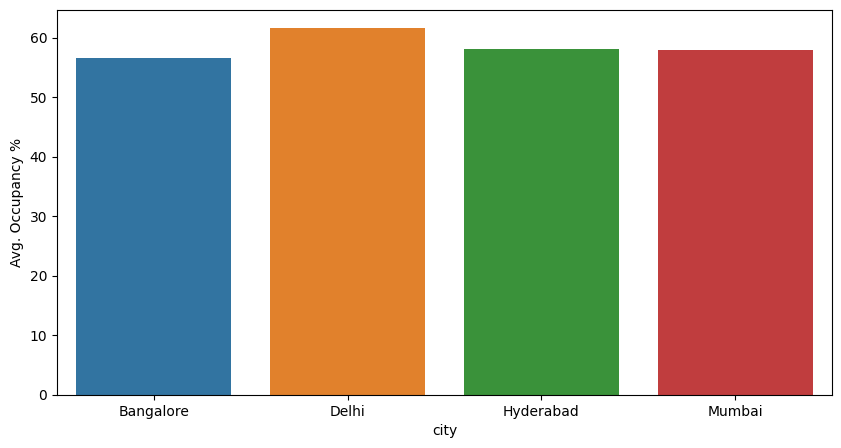

In [192]:
# vizualise avg occ percentage
plt.figure(figsize=(10,5))
sns.barplot(x=df_avg_occperct_across_cities['city'],y=df_avg_occperct_across_cities['Avg. Occupancy %'])
plt.show()

**INFERENCE:** 
* `Delhi` leads with maximum occupancy rate with the rest nearly the same.

#### AVG OCCUPANCY RATE ACROSS PROPERTIES PRESENT IN DIFFERENT CITIES

In [195]:
# compute avg occupancy rate across properties city and propertywise
df_avgoccperct_across_properties_and_cities= df_agg_bookings_hotelwise.groupby(['city','property_name'])['occupancy_perct'].agg(['mean']).rename(columns={'mean':'Avg. Occupancy %'}).reset_index()

In [197]:
df_avgoccperct_across_properties_and_cities

,city,property_name,Avg. Occupancy %
0,Bangalore,Atliq Bay,65.954430
1,Bangalore,Atliq Blu,53.197910
2,Bangalore,Atliq City,66.734854
3,Bangalore,Atliq Exotica,54.722419
4,Bangalore,Atliq Grands,45.089709
5,Bangalore,Atliq Palace,53.865047
6,Delhi,Atliq Bay,54.194957
7,Delhi,Atliq Blu,65.789553
8,Delhi,Atliq City,53.572913
9,Delhi,Atliq Grands,67.697823


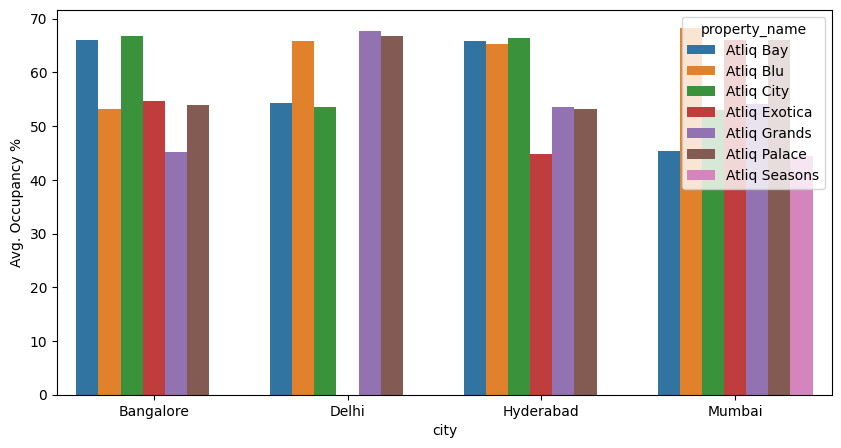

In [198]:
# visualize
plt.figure(figsize=(10,5))
sns.barplot(x=df_avgoccperct_across_properties_and_cities['city'],y=df_avgoccperct_across_properties_and_cities['Avg. Occupancy %'],hue=df_avgoccperct_across_properties_and_cities['property_name'])
plt.show()

**INFERENCE:**
* `Atliq Blu` in **Mumbai** has the highest Avg. Occupancy rate amongst all followed by **Delhi's** `Atliq Grandis`. 
* `Atliq Seasons` is a new property opened up in **Mumbai** and has the lowest avg. occupancy rate followed by **Hyderabad's** `Atliq Exotica`.

#### AVG OCCUPANCY RATE ON WEEKENDS AND WEEKDAYS

In [208]:
df_date.head()

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


In [209]:
df_agg_bookings_hotelwise.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_perct,property_name,category,city
0,16558,1-May-22,RT1,18,19.0,94.736842,Atliq Grands,Luxury,Delhi
1,16558,1-May-22,RT2,21,22.0,95.454545,Atliq Grands,Luxury,Delhi
2,16558,1-May-22,RT3,8,8.0,100.000000,Atliq Grands,Luxury,Delhi
3,16558,1-May-22,RT4,3,3.0,100.000000,Atliq Grands,Luxury,Delhi
4,16558,2-May-22,RT1,12,19.0,63.157895,Atliq Grands,Luxury,Delhi


NOTE:
* To merge *df_agg_bookings_hotelwise* & *df_date* we first perform groupby on **check_in_date** in the former computing avg. occupancy rate for each date.
* Convert *date* in the *df_date* to match the dates in groupby dataframe. 
* Merge on *check_in_date* and *date*.

In [211]:
df_agg_bookings_hotelwise_datewise = df_agg_bookings_hotelwise.groupby(['check_in_date'])['occupancy_perct'].agg(['mean']).reset_index()
df_agg_bookings_hotelwise_datewise.head()

,check_in_date,mean
0,1-Jul-22,55.658980
1,1-Jun-22,45.367132
2,1-May-22,82.033574
3,10-Jul-22,80.173858
4,10-Jun-22,56.735788


In [216]:
df_date['date'] = df_date['date'].apply(lambda x: x[1:] if x[0]=='0' else x)
df_date.head()

,date,mmm yy,week no,day_type
0,1-May-22,May 22,W 19,weekend
1,2-May-22,May 22,W 19,weekeday
2,3-May-22,May 22,W 19,weekeday
3,4-May-22,May 22,W 19,weekeday
4,5-May-22,May 22,W 19,weekeday


In [218]:
df_agg_bookings_hotelwise_datewise.rename(columns={'mean':'Avg. Occ %'},inplace=True)
df_agg_bookings_hotelwise_datewise.columns

Index(['check_in_date', 'Avg. Occ %'], dtype='object')

In [224]:
# merge dataframes
df_daytypewise_avgoccperct = pd.merge(left=df_agg_bookings_hotelwise_datewise,right=df_date,left_on='check_in_date',right_on='date',how='outer')

In [225]:
df_daytypewise_avgoccperct.head()

,check_in_date,Avg. Occ %,date,mmm yy,week no,day_type
0,1-Jul-22,55.658980,1-Jul-22,Jul 22,W 27,weekeday
1,1-Jun-22,45.367132,1-Jun-22,Jun 22,W 23,weekeday
2,1-May-22,82.033574,1-May-22,May 22,W 19,weekend
3,10-Jul-22,80.173858,10-Jul-22,Jul 22,W 29,weekend
4,10-Jun-22,56.735788,10-Jun-22,Jun 22,W 24,weekeday


In [228]:
df_daytype_avgoccperct_count = df_daytypewise_avgoccperct.groupby(['day_type'])['Avg. Occ %'].agg(['mean']).reset_index().rename(columns={'mean':'Avg. Occ %'})
df_daytype_avgoccperct_count.head()

,day_type,Avg. Occ %
0,weekeday,51.822307
1,weekend,74.246776


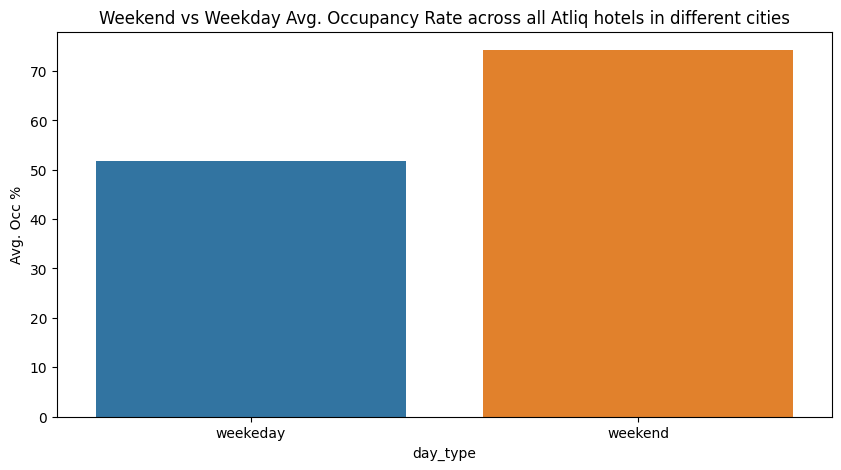

In [230]:
# Visualize
plt.figure(figsize=(10,5))
sns.barplot(x=df_daytype_avgoccperct_count['day_type'],y=df_daytype_avgoccperct_count['Avg. Occ %'])
plt.title(f'Weekend vs Weekday Avg. Occupancy Rate across all Atliq hotels in different cities')
plt.show()

**INFERENCE:**
* *Weekend* sees more avg. occupancy rate compared to *weekdays* which is expected since people usually go on vacation on *weekend* than on *weekdays*.

#### AVG OCCUPANCY RATE MONTHWISE

In [231]:
df_monthwise_avgoccrate = df_daytypewise_avgoccperct.groupby(['mmm yy'])['Avg. Occ %'].agg(['mean']).reset_index().rename(columns={'mean':'Avg. Occ %'})
df_monthwise_avgoccrate.head()

,mmm yy,Avg. Occ %
0,Jul 22,58.116188
1,Jun 22,58.057185
2,May 22,59.025663


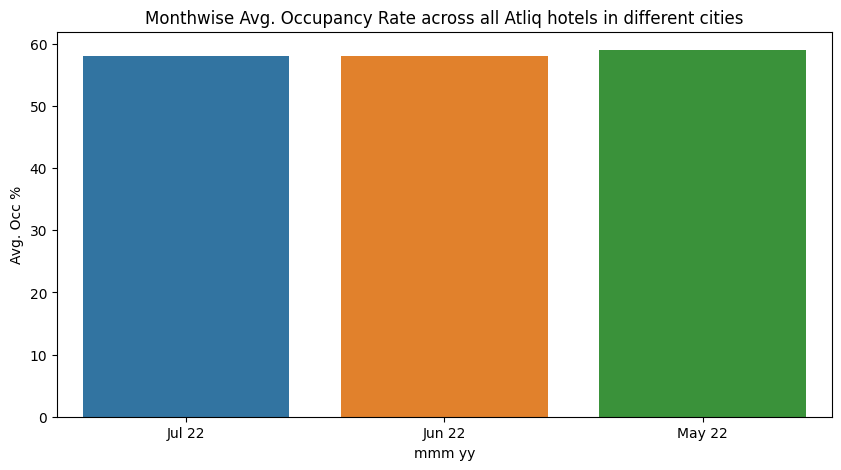

In [233]:
# visualize
plt.figure(figsize=(10,5))
sns.barplot(x=df_monthwise_avgoccrate['mmm yy'],y=df_monthwise_avgoccrate['Avg. Occ %'])
plt.title(f'Monthwise Avg. Occupancy Rate across all Atliq hotels in different cities')
plt.show()

INFERENCE:
* Across different months *Avg Occupancy Rate* has stayed nearly the same.

#### GATHER ALL DATA 
We combine latest *df_august* data to the *df_bookings* dataframe to get the whole record till the latest date. 

In [236]:
df_august_bookings.head()

,property_id,property_name,category,city,room_category,room_class,check_in_date,mmm yy,week no,day_type,successful_bookings,capacity,occ%
0,16559,Atliq Exotica,Luxury,Mumbai,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,30,100.00
1,19562,Atliq Bay,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,21,30,70.00
2,19563,Atliq Palace,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,23,30,76.67
3,19558,Atliq Grands,Luxury,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,30,40,75.00
4,19560,Atliq City,Business,Bangalore,RT1,Standard,01-Aug-22,Aug-22,W 32,weekeday,20,26,76.92


In [239]:
df_bookings.columns

Index(['booking_id', 'property_id', 'booking_date', 'check_in_date',
       'checkout_date', 'no_guests', 'room_category', 'room_no',
       'booking_platform', 'ratings_given', 'booking_status',
       'revenue_generated', 'revenue_realized'],
      dtype='object')

In [240]:
df_august_bookings.columns

Index(['property_id', 'property_name', 'category', 'city', 'room_category',
       'room_class', 'check_in_date', 'mmm yy', 'week no', 'day_type',
       'successful_bookings', 'capacity', 'occ%'],
      dtype='object')

In [243]:
# get common cols for both df_bookings & df_august_bookings.
common_cols = set(df_bookings.columns).intersection(set(df_august_bookings.columns))
common_cols

{'check_in_date', 'property_id', 'room_category'}

In [246]:
# concatenate rowwise 'df_august_bookings' & 'df_bookings' to get latest report
df_latest = pd.concat([df_bookings,df_august_bookings],ignore_index=True,axis=0)
df_latest.tail(5)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,room_no,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
128295,NaN,19563,NaN,01-Aug-22,NaN,NaN,RT1,NaN,NaN,NaN,NaN,NaN,NaN
128296,NaN,19558,NaN,01-Aug-22,NaN,NaN,RT1,NaN,NaN,NaN,NaN,NaN,NaN
128297,NaN,19560,NaN,01-Aug-22,NaN,NaN,RT1,NaN,NaN,NaN,NaN,NaN,NaN
128298,NaN,17561,NaN,01-Aug-22,NaN,NaN,RT1,NaN,NaN,NaN,NaN,NaN,NaN
128299,NaN,17564,NaN,01-Aug-22,NaN,NaN,RT1,NaN,NaN,NaN,NaN,NaN,NaN


#### CITYWISE REVENUE REALIZED BY ATLIQ

In [249]:
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,room_no,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
index,,,,,,,,,,,,,
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,2,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,5,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,6,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,7,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,8,logtrip,NaN,No Show,9100,9100


In [250]:
df_hotels.head()

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [251]:
# merge the above dataframes to get citywise revenue generated
df_citywise_revenuerealised = pd.merge(left=df_bookings,right=df_hotels,on='property_id',how='outer')
df_citywise_revenuerealised.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,room_no,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,2,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,5,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi
2,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,6,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi
3,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,7,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
4,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,8,logtrip,NaN,No Show,9100,9100,Atliq Grands,Luxury,Delhi


In [252]:
# groupby to get citywise revenue realised
df_revenuegenerated_per_city = df_citywise_revenuerealised.groupby(['city'])['revenue_realized'].agg(['sum']).reset_index().rename(columns={'sum':'Total Revenue Generated'})
df_revenuegenerated_per_city

,city,Total Revenue Generated
0,Bangalore,400334940
1,Delhi,284483752
2,Hyderabad,325179310
3,Mumbai,516960803


In [254]:
df_revenuegenerated_per_city['Revenue %'] = (df_revenuegenerated_per_city['Total Revenue Generated']/df_revenuegenerated_per_city['Total Revenue Generated'].sum())*100
df_revenuegenerated_per_city.head()

,city,Total Revenue Generated,Revenue %
0,Bangalore,400334940,26.217796
1,Delhi,284483752,18.630742
2,Hyderabad,325179310,21.295880
3,Mumbai,516960803,33.855583


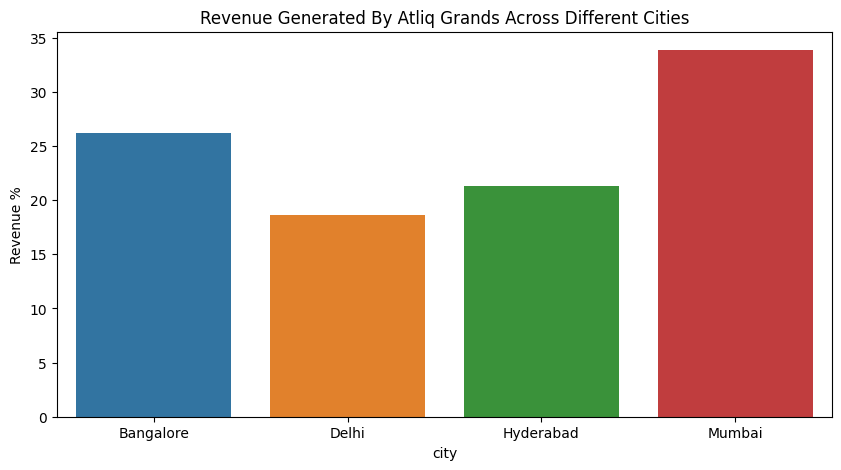

In [256]:
# visualize
plt.figure(figsize=(10,5))
sns.barplot(data=df_revenuegenerated_per_city,x='city',y='Revenue %')
plt.title('Revenue Generated By Atliq Grands Across Different Cities')
plt.show()

INFERENCE:
* `Mumbai` generates the highest revenue over all other cities. This could explain the opening of a new property `Atliq Seasons`. 
* `Delhi` generates the lowest revenue. 

#### MONTHWISE REVENUE

In [262]:
df_date.head()

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


In [261]:
df_bookings.tail(10)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,room_no,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
index,,,,,,,,,,,,,
134570,Jul312217564RT32,17564,31-07-22,31-07-22,3/8/2022,4.0,RT3,2,journey,NaN,Cancelled,24480,9792
134571,Jul312217564RT33,17564,30-07-22,31-07-22,4/8/2022,3.0,RT3,3,direct online,NaN,Checked Out,22440,22440
134572,Jul312217564RT34,17564,7/7/2022,31-07-22,1/8/2022,1.0,RT3,4,direct online,1.0,Checked Out,20400,20400
134573,Jul312217564RT35,17564,31-07-22,31-07-22,1/8/2022,2.0,RT3,5,direct online,NaN,No Show,20400,20400
134574,Jul312217564RT36,17564,31-07-22,31-07-22,1/8/2022,1.0,RT3,6,others,NaN,Checked Out,20400,20400
134575,Jul312217564RT37,17564,31-07-22,31-07-22,3/8/2022,6.0,RT3,7,others,2.0,Checked Out,28560,28560
134576,Jul312217564RT38,17564,30-07-22,31-07-22,4/8/2022,1.0,RT3,8,others,NaN,Checked Out,20400,20400
134577,Jul312217564RT39,17564,30-07-22,31-07-22,6/8/2022,2.0,RT3,9,tripster,2.0,Checked Out,20400,20400
134578,Jul312217564RT310,17564,31-07-22,31-07-22,2/8/2022,1.0,RT3,10,others,2.0,Checked Out,20400,20400


We can simply extract from *booking_id* the first 3 letters denoting month and get the total revenue realized per month.

In [263]:
df_bookings['month_booked'] = df_bookings['booking_id'].str[:3]
df_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,room_no,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,month_booked
index,,,,,,,,,,,,,,
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,2,others,NaN,Cancelled,9100,3640,May
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,5,direct online,5.0,Checked Out,10920,10920,May
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,6,others,4.0,Checked Out,9100,9100,May
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,7,others,NaN,Cancelled,9100,3640,May
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,8,logtrip,NaN,No Show,9100,9100,May


In [265]:
df_monthwise_revenuegenerated = df_bookings.groupby(['month_booked'])['revenue_realized'].agg(['sum']).reset_index().rename(columns={'sum':'Total revenue_realized'})
df_monthwise_revenuegenerated

,month_booked,Total revenue_realized
0,Jul,511891576
1,Jun,494594327
2,May,520472902


In [266]:
df_monthwise_revenuegenerated['Rev %'] = (df_monthwise_revenuegenerated['Total revenue_realized']/df_monthwise_revenuegenerated['Total revenue_realized'].sum())*100
df_monthwise_revenuegenerated

,month_booked,Total revenue_realized,Rev %
0,Jul,511891576,33.523601
1,Jun,494594327,32.390810
2,May,520472902,34.085589


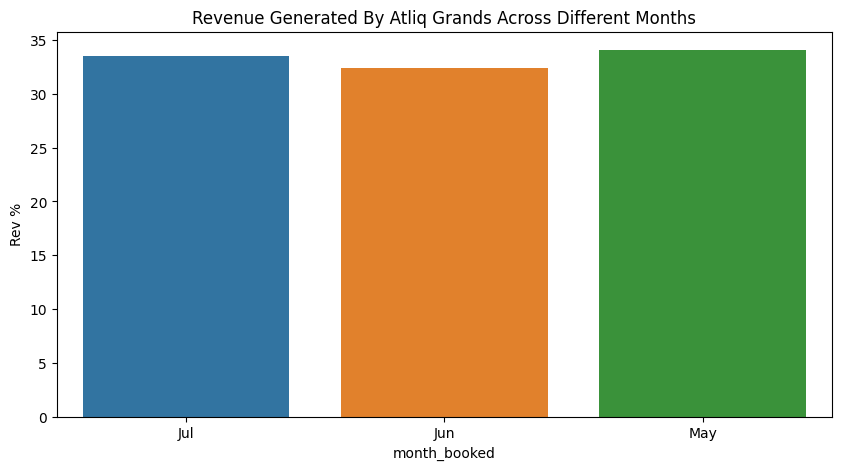

In [267]:
# visualize
plt.figure(figsize=(10,5))
sns.barplot(data=df_monthwise_revenuegenerated,x='month_booked',y='Rev %')
plt.title('Revenue Generated By Atliq Grands Across Different Months')
plt.show()

INFERENCE:
* `May` sees a slightly higher revenue as compared to other months.